<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/29_09_ModuloII_CotasRioNegro_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Este exercício utiliza um arquivo CSV com as colunas Data e Cota. A série é dividida em treino, validação e teste, normalizada, transformada em janelas e usada para comparar RNN e LSTM.


# Célula 1 - Importar bibliotecas


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint


# Célula 2 - Abrir e preparar o dataset


In [35]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cotas_RioNegro2020a2026.csv")

df["Data"] = pd.to_datetime(
    df["Data"],
    format='mixed',
    dayfirst=True
)

df = df.sort_values("Data")
df = df.dropna(subset=["Data", "Cota"])

# Convertendo colunas numéricas com separador decimal ',' para '.' e depois para float
for col in ["Cota", "Cota"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print(df.head())
df.info()

        Data   Cota
0 2020-01-01  14.40
1 2020-01-03  14.39
2 2020-01-05  14.59
3 2020-01-08  14.87
4 2020-01-10  14.72
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Data    1000 non-null   datetime64[ns]
 1   Cota    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.8 KB


# Célula 3 - Visualizar a série

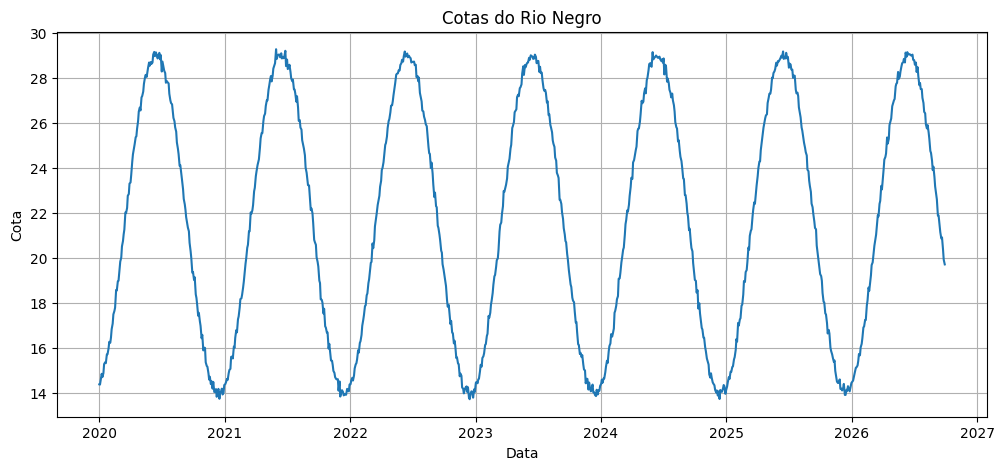

In [53]:
plt.figure(figsize=(12, 5))
plt.plot(df["Data"], df["Cota"])
plt.title("Cotas do Rio Negro")
plt.xlabel("Data")
plt.ylabel("Cota")
plt.grid(True)
plt.show()

# Célula 4 - Separar a variável

In [38]:
dados = df[["Cota"]].values

print("Quantidade de registros:", len(dados))
print("Formato:", dados.shape)

Quantidade de registros: 1000
Formato: (1000, 1)


# Célula 5 - Separar treino, validação e teste


In [39]:
n = len(dados)
fim_treino = int(n * 0.70)
fim_val = int(n * 0.85)

treino = dados[:fim_treino]
validacao = dados[fim_treino:fim_val]
teste = dados[fim_val:]


# Célula 6 - Normalizar


In [40]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaler.fit(treino)

treino_norm = scaler.transform(treino)
validacao_norm = scaler.transform(validacao)
teste_norm = scaler.transform(teste)


# Célula 7 - Criar janelas de 12 períodos


In [41]:
janela = 12

def criar_janelas(dados, janela):
    X = []
    y = []

    for i in range(len(dados) - janela):
        X.append(dados[i:i + janela])
        y.append(dados[i + janela])

    return np.array(X), np.array(y)

X_train, y_train = criar_janelas(treino_norm, janela)
X_val, y_val = criar_janelas(validacao_norm, janela)
X_test, y_test = criar_janelas(teste_norm, janela)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (688, 12, 1)
X_val: (138, 12, 1)
X_test: (138, 12, 1)


# Célula 8 - Criar a RNN

In [42]:
modelo_rnn = Sequential([
    Input(shape=(12, 1)),
    SimpleRNN(32, activation="tanh"),
    Dense(1)
])

modelo_rnn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Célula 9 - Checkpoint e treinamento da RNN


In [43]:
checkpoint_rnn = ModelCheckpoint(
    "melhor_rnn.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

history_rnn = modelo_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[checkpoint_rnn]
)


Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.1205 - mae: 0.2321 - val_loss: 0.0139 - val_mae: 0.1015
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0075 - mae: 0.0706 - val_loss: 0.0031 - val_mae: 0.0487
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023 - mae: 0.0396 - val_loss: 0.0019 - val_mae: 0.0373
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0335 - val_loss: 0.0015 - val_mae: 0.0345
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - mae: 0.0315 - val_loss: 0.0012 - val_mae: 0.0306
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - mae: 0.0302 - val_loss: 0.0012 - val_mae: 0.0303
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - mae: 0.0294 - val_loss: 0.0011 - val_mae: 0.0291
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - mae: 0.0280 - val_loss: 9.8929e-04 - val_mae: 0.0272
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l

# Célula 10 - Criar a LSTM

In [44]:
modelo_lstm = Sequential([
    Input(shape=(12, 1)),
    LSTM(32),
    Dense(1)
])

modelo_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Célula 11 - Checkpoint e treinamento da LSTM

In [45]:
checkpoint_lstm = ModelCheckpoint(
    "melhor_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

history_lstm = modelo_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[checkpoint_lstm]
)


Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1540 - mae: 0.2921 - val_loss: 0.0178 - val_mae: 0.1068
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0204 - mae: 0.1178 - val_loss: 0.0149 - val_mae: 0.1088
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0114 - mae: 0.0946 - val_loss: 0.0089 - val_mae: 0.0828
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0085 - mae: 0.0826 - val_loss: 0.0074 - val_mae: 0.0780
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0076 - mae: 0.0789 - val_loss: 0.0069 - val_mae: 0.0751
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0072 - mae: 0.0771 - val_loss: 0.0067 - val_mae: 0.0732
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0070 - mae: 0.0754 - val_loss: 0.0066 - val_mae: 0.0723
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067 - mae: 0.0739 - val_loss: 0.0062 - val_mae: 0.0705
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - lo

# Célula 12 - Comparar val_loss

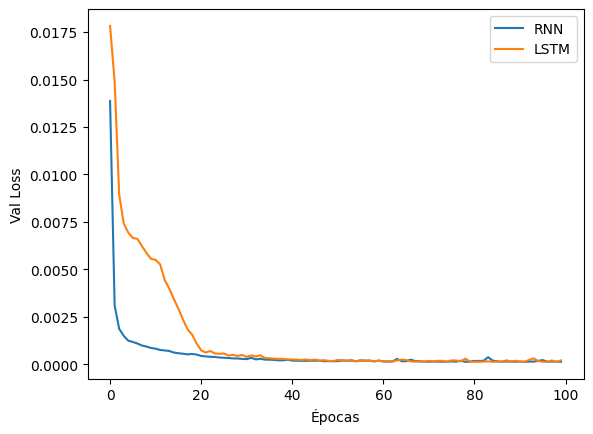

In [46]:
plt.plot(
    history_rnn.history["val_loss"],
    label="RNN"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="LSTM"
)

plt.xlabel("Épocas")
plt.ylabel("Val Loss")
plt.legend()
plt.show()


# Célula 13 - Carregar os melhores modelos

In [47]:
melhor_rnn = load_model("melhor_rnn.keras")
melhor_lstm = load_model("melhor_lstm.keras")


# Célula 14 - Avaliar no teste

In [48]:
loss_rnn, mae_rnn = melhor_rnn.evaluate(
    X_test, y_test, verbose=0
)

loss_lstm, mae_lstm = melhor_lstm.evaluate(
    X_test, y_test, verbose=0
)

print("RNN - Loss:", loss_rnn, "MAE:", mae_rnn)
print("LSTM - Loss:", loss_lstm, "MAE:", mae_lstm)


RNN - Loss: 0.00014482371625490487 MAE: 0.009652119129896164
LSTM - Loss: 0.00012947944924235344 MAE: 0.009172779507935047


# Célula 15 - Fazer previsões


In [49]:
prev_rnn = melhor_rnn.predict(
    X_test,
    verbose=0
)

prev_lstm = melhor_lstm.predict(
    X_test,
    verbose=0
)


# Célula 16 - Voltar à escala original

In [50]:
prev_rnn_real = scaler.inverse_transform(prev_rnn)
prev_lstm_real = scaler.inverse_transform(prev_lstm)

real = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)


# Célula 17 - Calcular MAE e RMSE

In [51]:
mae_rnn = mean_absolute_error(
    real,
    prev_rnn_real
)

rmse_rnn = np.sqrt(
    mean_squared_error(real, prev_rnn_real)
)

mae_lstm = mean_absolute_error(
    real,
    prev_lstm_real
)

rmse_lstm = np.sqrt(
    mean_squared_error(real, prev_lstm_real)
)

print("RNN - MAE:", mae_rnn, "RMSE:", rmse_rnn)
print("LSTM - MAE:", mae_lstm, "RMSE:", rmse_lstm)


RNN - MAE: 0.15009041965871625 RMSE: 0.18713289295392493
LSTM - MAE: 0.14263671349788068 RMSE: 0.17694198391059088


# Célula 18 - Real × RNN × LSTM

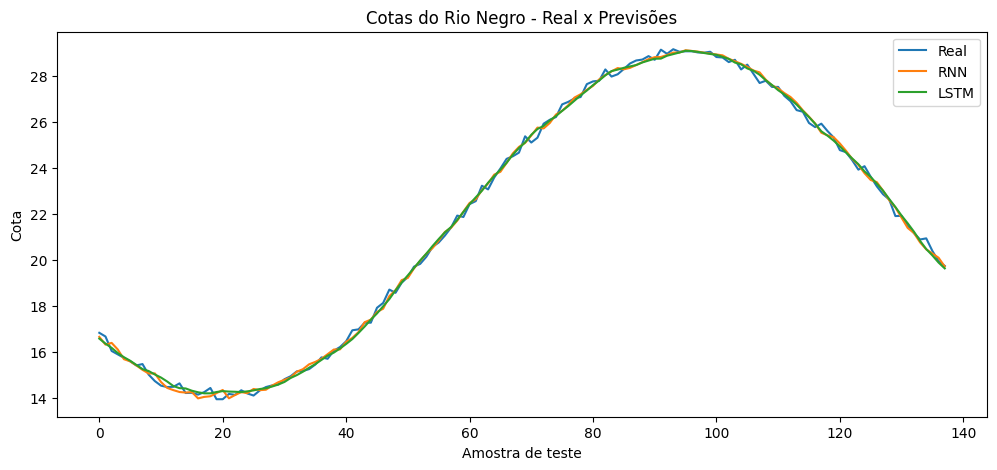

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(real.flatten(), label="Real")
plt.plot(prev_rnn_real.flatten(), label="RNN")
plt.plot(prev_lstm_real.flatten(), label="LSTM")

plt.title("Cotas do Rio Negro - Real x Previsões")
plt.xlabel("Amostra de teste")
plt.ylabel("Cota")
plt.legend()
plt.show()


7. Leitura dos resultados

Indicador         | O que mostra                 | Leitura básica


---


loss / val_loss   | Erro durante o treinamento   | Curvas próximas e em queda                                              são um bom sinal inicial



---


MAE                | Erro absoluto médio         | Quanto menor, melhor; mesma   unidade da variável


---


RMSE               | Erro com maior peso para erros grandes | Quanto menor, melhor; compare com o MAE


---


Real × Previsto  | Acompanhamento visual  | Curvas mais próximas indicam previsões mais próximas



8. Resumo final
DADOS
  ↓

LIMPEZA E ORGANIZAÇÃO
  ↓

TREINO | VALIDAÇÃO | TESTE
  ↓

NORMALIZAÇÃO
  ↓

JANELAS TEMPORAIS
  ↓

Input(shape=(TEMPO, CARACTERÍSTICAS))
  ↓

RNN ou LSTM
  ↓

Dense(1)
  ↓

TREINAMENTO
  ↓

LOSS × VAL_LOSS
  ↓

MELHOR MODELO
  ↓

TESTE
  ↓

PREVISÕES
  ↓

INVERSÃO DA NORMALIZAÇÃO
  ↓

REAL × PREVISTO
  ↓

MAE + RMSE
  ↓
  
INTERPRETAÇÃO


Regra central: o primeiro número do Input indica quanto do passado será observado; o segundo indica quantas informações existem em cada momento.

A lógica da previsão pode ser resumida assim: uma sequência do passado é apresentada à rede para que ela aprenda padrões temporais e estime o próximo valor.

